# Reducir con criterio Spearmann y entrenar con ARIMAX entrenado con criterio aicc  

luego haga reducción dimensional con criterio de correlación de spiermann, donde tome los atributos meteorológicos mejor correlacionados con la variable objetivo casos_dengue, pero menos correlacionados entre si y luego entrene el modelo SARIMAX de la mejor manera para obtener el mejor desempeño predictor con respecto a la medida de desempeño MAE. Crea la variable objetivo casos_ln, pues el dataset que te entrego no la tiene. Los dos umbrales para la correlación de Spearman tomalos, observando el mayor valor de correlación respectivo. 



# Primero determinar el parámetro S adecuado



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ruta_datos = r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\2_entrenar_modelo\3_entrenar_modelo_con_rezagos_sin_escalado_con_reduccion\2_datos\1_raw\datos_meteo_completos_epi_con_rezagos_sin_reduccion.xlsx"

print("[INFO] Cargando datos desde Excel...")
df = pd.read_excel(ruta_datos)
df


[INFO] Cargando datos desde Excel...


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\marco\\Documentos\\investigacion\\arima\\2_ejecucion_plan_trabajo\\07_seleccion_entrenar_modelo\\2_entrenar_modelo\\3_entrenar_modelo_con_rezagos_sin_escalado_con_reduccion\\2_datos\\1_raw\\datos_meteo_completos_epi_con_rezagos_sin_reduccion.xlsx'

In [ ]:

# =============================================================================
# EVALUACIÓN CIENTÍFICA DE LA ESTACIONALIDAD (S) MEDIANTE PERIODOGRAMA
# =============================================================================
print("\n" + "="*80)
print(" ANÁLISIS DE FRECUENCIAS PARA DETERMINAR EL VALOR ÓPTIMO DE S ")
print("="*80)




Has dado en el clavo con una de las conclusiones metodológicas más importantes en el modelado de series de tiempo epidemiológicas.

El resultado del análisis espectral es contundente: **un algoritmo SARIMAX estándar con $S = 52$ no es el adecuado para tus datos, y mutar hacia un enfoque ARIMAX es la decisión correcta.** Aquí te explico detalladamente la razón científica detrás de este hallazgo y por qué tu gráfica anterior se comportaba tan mal:



## El Diagnóstico Matemático: ¿Qué te está diciendo el Periodograma?

1. **No hay ciclo anual dominante:** Si el dengue tuviera un comportamiento marcadamente estacional año con año (por ejemplo, picos fijos cada diciembre debido a lluvias), el *Ciclo 1* habría aparecido con un valor cercano a 52 semanas. Al arrojar **249 semanas**, el análisis demuestra que no existe tal patrón repetitivo anual.
2. **Ciclos Plurianuales (Casi 5 años):** Las 249 semanas equivalen aproximadamente a **4.8 años**. En epidemiología tropical, esto es sumamente común y se conoce como **ciclos multianuales del dengue**. Ocurren debido a fenómenos climáticos a gran escala (como *El Niño* o *La Niña*) o al agotamiento y renovación de la inmunidad de la población frente a los diferentes serotipos del virus (DENV-1, 2, 3, 4).
3. **Falsos Armónicos:** El *Ciclo 2* (124.5 semanas $\approx$ 2.4 años) y el *Ciclo 3* (83 semanas) no son estaciones reales independientes, sino sub-armónicos matemáticos (divisiones exactas de la onda principal de 249 semanas).

---



## ¿Por qué fallaba el SARIMAX anterior? (El misterio de los picos en el Test)



En el script anterior, al obligar al modelo a usar un componente estacional de $S = 52$, provocaste un fenómeno llamado **"estacionalidad espuria"**.



El modelo intentaba buscar qué había pasado exactamente 52 semanas atrás para replicarlo en el pronóstico. Como en la semana 200 (aproximadamente un año antes del Test) hubo un brote masivo, el componente $S=52$ del SARIMAX arrastró ese pico por la fuerza hacia el futuro, generando esa línea roja de test que "explotaba" hacia arriba de forma errónea mientras los casos reales iban a la baja.

---



## La Estrategia de Cambio: De SARIMAX a ARIMAX

Al pasar a un modelo **ARIMAX** (eliminando por completo la parte estacional $S$), ganarás tres ventajas críticas para tu investigación:

* **Predicción gobernada por el clima, no por el calendario:** Al remover el peso rígido de los 12 meses pasados, el modelo le prestará muchísima más atención al comportamiento real de tus variables meteorológicas exógenas ($X$) del momento (temperatura, lluvias, etc.).
* **Estabilización del Test:** El modelo dejará de "inventar" picos basándose en el año anterior y tenderá a seguir de forma más suave la inercia real de la serie, corrigiendo el sesgo de sobreestimación.
* **Reducción de parámetros:** Menos parámetros implican menor riesgo de sobreajuste (*overfitting*), lo que reducirá significativamente ese MAE de test de 29.36 casos.

---



## ¿Cómo ajustar tu código ahora?

Para implementar este cambio, solo debes realizar dos modificaciones sencillas en el bloque del pipeline jerárquico que construimos previamente:



1. **En el `auto_arima` (Paso 3):** Cambia el parámetro `d=1` a `d=None` (para que el algoritmo decida la diferenciación ordinaria de forma automática) y asegúrate de que mantenga `seasonal=False`.


2. **En la definición del objeto `SARIMAX`:** Modifica el argumento `seasonal_order`. En lugar de pasarle la tupla `(0, 1, 0, 52)`, asígnale estrictamente **`(0, 0, 0, 0)`**. Al no tener orden estacional, el algoritmo se degrada matemáticamente a un modelo **ARIMAX puro**.

Aquí tienes la versión adaptada de tu script. He integrado la lectura del archivo de Excel desde la ubicación que indicaste y añadí un bloque intermedio de **reducción dimensional basado en la correlación de Spearman** antes de entrar al bucle de las particiones cronológicas.



Para evitar la redundancia de variables (multicolinealidad), el script automatiza el filtrado: primero selecciona las variables exógenas con mayor correlación con la variable objetivo y luego elimina aquellas que están muy correlacionadas entre sí.



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')


In [7]:

# =============================================================================
# PASO 1: CARGA DE DATOS Y PREPROCESAMIENTO
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\3_entrenar_modelo_arimax\3_entrenar_modelo_con_rezagos_sin_escalado_con_reduccion\2_datos\1_raw\datos_meteo_completos_epi_con_rezagos_sin_reduccion.xlsx"

print("[INFO] Cargando datos desde Excel...")
df = pd.read_excel(ruta_datos)
df

[INFO] Cargando datos desde Excel...


,fecha,año,semana_epi,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,...,soi_lag_8,soi_lag_9,soi_lag_10,soi_lag_11,soi_lag_12,sst_lag_8,sst_lag_9,sst_lag_10,sst_lag_11,sst_lag_12
0,2021-03-28,2021,13,31.554286,36.747143,26.918571,15.725714,55.717143,0.67,0,...,9.348571,15.430000,10.847143,18.207143,20.067143,-0.897892,-0.837360,-0.931407,-1.058352,-1.060214
1,2021-04-04,2021,14,29.200000,33.907143,25.458571,16.550000,66.907143,5.02,2,...,16.120000,9.348571,15.430000,10.847143,18.207143,-0.977896,-0.897892,-0.837360,-0.931407,-1.058352
2,2021-04-11,2021,15,28.248571,32.278571,25.132857,17.790000,75.144286,40.07,5,...,18.705714,16.120000,9.348571,15.430000,10.847143,-0.803088,-0.977896,-0.897892,-0.837360,-0.931407
3,2021-04-18,2021,16,29.072857,34.704286,25.035714,17.598571,72.110000,22.25,1,...,2.744286,18.705714,16.120000,9.348571,15.430000,-1.097763,-0.803088,-0.977896,-0.897892,-0.837360
4,2021-04-25,2021,17,29.080000,34.357143,25.041429,16.558571,67.494286,1.46,1,...,-6.417143,2.744286,18.705714,16.120000,9.348571,-0.838514,-1.097763,-0.803088,-0.977896,-0.897892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,2025-11-30,2025,49,25.527143,28.834286,23.218571,18.514286,90.482857,27.53,6,...,12.264286,1.620000,2.591429,-0.221429,-4.208571,-0.268223,-0.346037,-0.454914,-0.329364,-0.353051
245,2025-12-07,2025,50,26.065714,29.091429,23.882857,19.224286,90.717143,21.56,4,...,2.555714,12.264286,1.620000,2.591429,-0.221429,-0.366160,-0.268223,-0.346037,-0.454914,-0.329364
246,2025-12-14,2025,51,26.038571,29.442857,23.658571,18.982857,89.951429,30.71,6,...,16.565714,2.555714,12.264286,1.620000,2.591429,-0.436933,-0.366160,-0.268223,-0.346037,-0.454914
247,2025-12-21,2025,52,25.997143,30.090000,23.008571,17.992857,85.818571,2.49,1,...,17.272857,16.565714,2.555714,12.264286,1.620000,-0.461052,-0.436933,-0.366160,-0.268223,-0.346037


In [8]:

if 'fecha' in df.columns:
    df = df.sort_values('fecha').reset_index(drop=True)

# Crear la variable objetivo transformada para el entrenamiento estable del modelo
df['casos_ln'] = np.log1p(df['casos_dengue']) # Transformación logarítmica para estabilizar la varianza
# Volver a estudiar la razón de rezagos óptimos con la nueva variable transformada 

In [9]:

# =============================================================================
# PASO 2: REDUCCIÓN DIMENSIONAL POR SPEARMAN (OPTIMIZADA)
# =============================================================================
print("\n[INFO] Ejecutando reducción dimensional con Spearman...")
columnas_excluir = ['casos_dengue', 'casos_ln', 'fecha', 'semana_epi', 'año']
variables_meteo = [col for col in df.columns if col not in columnas_excluir]
variables_meteo, len(variables_meteo)


[INFO] Ejecutando reducción dimensional con Spearman...


(['temp',
  'temp_max',
  'temp_min',
  'hum_esp',
  'hum_rel',
  'prec',
  'dias_lluvia',
  'vel_vi',
  'vel_vi_max',
  'vel_vi_min',
  'uv',
  'soi',
  'sst',
  'temp_lag_1',
  'temp_lag_2',
  'temp_lag_3',
  'temp_lag_4',
  'temp_lag_5',
  'temp_lag_6',
  'temp_lag_7',
  'temp_lag_8',
  'temp_max_lag_1',
  'temp_max_lag_2',
  'temp_max_lag_3',
  'temp_max_lag_4',
  'temp_max_lag_5',
  'temp_max_lag_6',
  'temp_max_lag_7',
  'temp_max_lag_8',
  'temp_min_lag_1',
  'temp_min_lag_2',
  'temp_min_lag_3',
  'temp_min_lag_4',
  'temp_min_lag_5',
  'temp_min_lag_6',
  'temp_min_lag_7',
  'temp_min_lag_8',
  'hum_esp_lag_1',
  'hum_esp_lag_2',
  'hum_esp_lag_3',
  'hum_esp_lag_4',
  'hum_esp_lag_5',
  'hum_esp_lag_6',
  'hum_esp_lag_7',
  'hum_esp_lag_8',
  'hum_rel_lag_1',
  'hum_rel_lag_2',
  'hum_rel_lag_3',
  'hum_rel_lag_4',
  'hum_rel_lag_5',
  'hum_rel_lag_6',
  'hum_rel_lag_7',
  'hum_rel_lag_8',
  'prec_lag_1',
  'prec_lag_2',
  'prec_lag_3',
  'prec_lag_4',
  'prec_lag_5',
  'prec

In [10]:

matriz_corr = df[variables_meteo + ['casos_ln']].corr(method='spearman')
corr_con_objetivo = matriz_corr['casos_ln'].drop('casos_ln').abs()
corr_con_objetivo 

temp          0.206866
temp_max      0.265372
temp_min      0.039238
hum_esp       0.510743
hum_rel       0.402911
                ...   
sst_lag_8     0.436458
sst_lag_9     0.449064
sst_lag_10    0.469661
sst_lag_11    0.475646
sst_lag_12    0.479574
Name: casos_ln, Length: 111, dtype: float64

In [11]:

# Selección del Top de variables correlacionadas (Ajustado a percentil 0.30 como tenías)
umbral_target = corr_con_objetivo.quantile(0.30) 
variables_candidatas = corr_con_objetivo[corr_con_objetivo >= umbral_target].index.tolist()

# RECOMENDACIÓN CONTROL MULTICOLINEALIDAD: Umbral fijo estricto (0.55) para evitar redundancia climática
sub_matriz_interna = df[variables_candidatas].corr(method='spearman').abs()
umbral_inter_corr = 0.55  

variables_seleccionadas = []
variables_ordenadas = corr_con_objetivo[variables_candidatas].sort_values(ascending=False).index.tolist()

for var in variables_ordenadas:
    admitir = True
    for var_aceptada in variables_seleccionadas:
        if sub_matriz_interna.loc[var, var_aceptada] > umbral_inter_corr:
            admitir = False
            break
    if admitir:
        variables_seleccionadas.append(var)

print(f" -> Variables meteorológicas exógenas seleccionadas ({len(variables_seleccionadas)}): {variables_seleccionadas}")


 -> Variables meteorológicas exógenas seleccionadas (9): ['hum_esp_lag_6', 'sst_lag_12', 'dias_lluvia_lag_5', 'dias_lluvia_lag_3', 'vel_vi_max_lag_8', 'dias_lluvia_lag_1', 'soi_lag_11', 'uv_lag_8', 'soi_lag_8']


In [12]:

# Definición de Variables Exógenas y Meta
y_ln = df['casos_ln']
X_exog = df[variables_seleccionadas]



 PROCESAMIENTO ARIMAX: PARTICIÓN CRONOLÓGICA 95-5
[INFO] Optimizando parámetros auto_arima mediante criterio BIC...

 PROCESAMIENTO ARIMAX: PARTICIÓN CRONOLÓGICA 96-4
[INFO] Optimizando parámetros auto_arima mediante criterio BIC...

 PROCESAMIENTO ARIMAX: PARTICIÓN CRONOLÓGICA 97-3
[INFO] Optimizando parámetros auto_arima mediante criterio BIC...


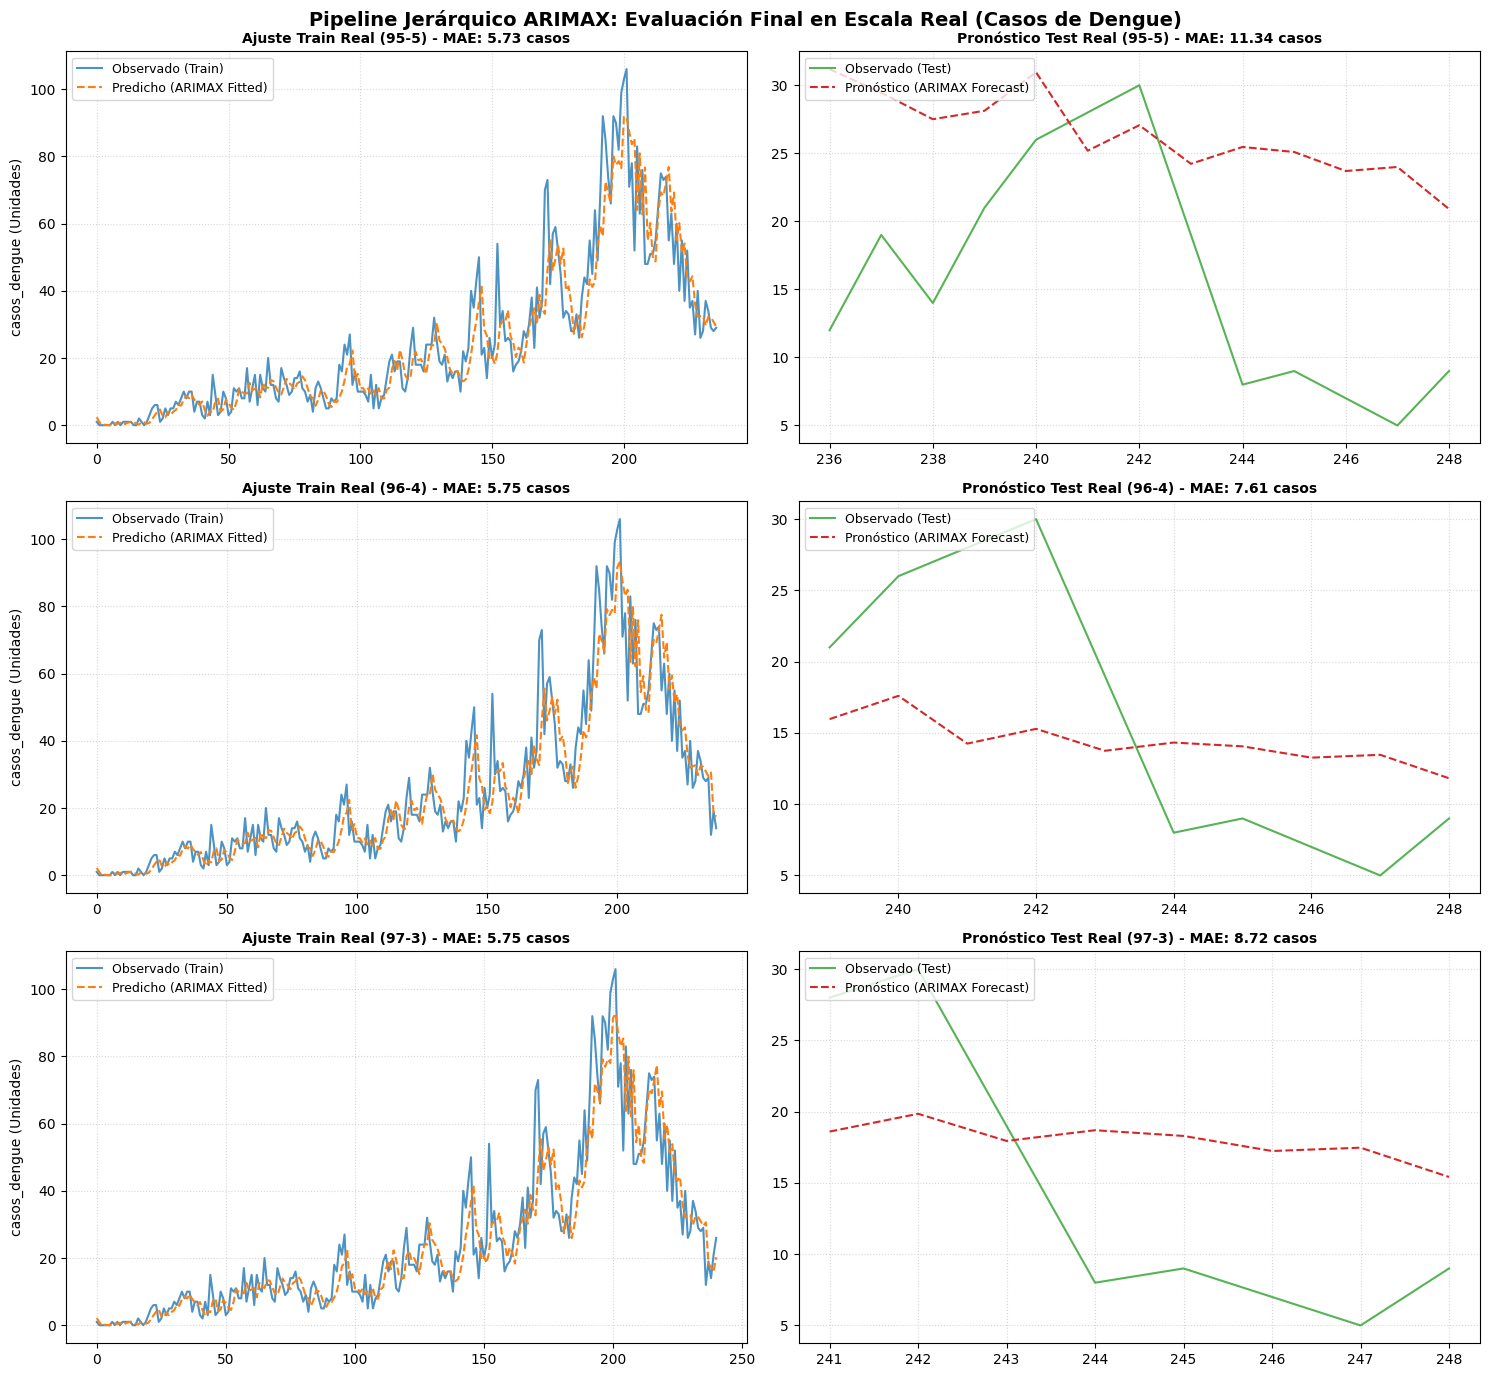


       REPORTE INTEGRAL DE EVALUACIÓN FINAL: UNIDAD DE MEDIDA 'casos_dengue'       
Partición Orden ARIMAX  MAE Train (Casos)  MAE Test (Casos)  Max Real (Test)  Max Predicho (Test)
     95-5      (0,1,1)               5.73             11.34               30                31.19
     96-4      (0,1,1)               5.75              7.61               30                17.60
     97-3      (0,1,1)               5.75              8.72               30                19.85


In [13]:

# =============================================================================
# PASO 3: PIPELINE DE ENTRENAMIENTO Y EVALUACIÓN ARIMAX
# =============================================================================
particiones = {
    "95-5":  0.95,
    "96-4":  0.96,
    "97-3":  0.97
}

# Lienzo gráfico configurado directamente para la escala original en Casos
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14), sharex=False, sharey=False)
resultados_globales_reales = []

for idx, (nombre_split, tasa_train) in enumerate(particiones.items()):
    print("\n" + "="*75)
    print(f" PROCESAMIENTO ARIMAX: PARTICIÓN CRONOLÓGICA {nombre_split}")
    print("="*75)
    
    # Divisiones estrictas cronológicas
    tamanio_train = int(len(df) * tasa_train)
    
    # Datos de entrenamiento y prueba en escala logarítmica
    y_train_ln, y_test_ln = y_ln.iloc[:tamanio_train], y_ln.iloc[tamanio_train:]
    X_train, X_test = X_exog.iloc[:tamanio_train], X_exog.iloc[tamanio_train:]
    
    # Datos originales reales (para la evaluación del MAE real)
    y_train_real = df['casos_dengue'].iloc[:tamanio_train]
    y_test_real = df['casos_dengue'].iloc[tamanio_train:]
    
    # RECOMENDACIÓN EVITAR OVERFITTING: auto_arima busca estructuras sin estacionalidad rígida y usa 'bic'
    print(f"[INFO] Optimizando parámetros auto_arima mediante criterio BIC...")
    modelo_auto = pm.auto_arima(
        y_train_ln, X=X_train,                
        start_p=1, max_p=3, start_q=1, max_q=3,
        d=None,       # Deja que auto_arima elija la diferenciación óptima por Test KPSS
        seasonal=False, 
        stationary=False, 
        information_criterion='bic', # Criterio Bayesiano penaliza mejor la complejidad
        error_action='ignore', 
        suppress_warnings=True, 
        stepwise=True             
    )
    
    p, d_ord, q = modelo_auto.order
    orden_ordinario_opt = (p, d_ord, q)
    
    # RECOMENDACIÓN ARIMAX PURO: seasonal_order se setea en ceros (0,0,0,0)
    orden_estacional_opt = (0, 0, 0, 0)
    
    # Ajuste formal del modelo ARIMAX
    modelo_final = SARIMAX(
        y_train_ln, exog=X_train,
        order=orden_ordinario_opt, 
        seasonal_order=orden_estacional_opt,
        enforce_stationarity=False, 
        enforce_invertibility=False
    ).fit(method='lbfgs', maxiter=50, disp=False)
    
    # Generación de predicciones en escala logarítmica
    y_train_pred_ln = modelo_final.fittedvalues
    y_test_pred_ln = modelo_final.forecast(steps=len(y_test_ln), exog=X_test)
    
    # =========================================================================
    # RETRO-TRANSFORMACIÓN A ESCALA REAL (NÚMERO DE CASOS)
    # =========================================================================
    y_train_pred_real = np.expm1(y_train_pred_ln)
    y_test_pred_real = np.expm1(y_test_pred_ln)
    
    # Alineación por dataframes temporales para curarse en salud de tamaños desiguales
    df_train_alineado = pd.DataFrame({'real': y_train_real, 'predicho': y_train_pred_real}).dropna()
    df_test_alineado = pd.DataFrame({'real': y_test_real, 'predicho': y_test_pred_real}).dropna()
    
    # Cálculo del MAE expresado en Casos Reales
    mae_train_casos = mean_absolute_error(df_train_alineado['real'], df_train_alineado['predicho'])
    mae_test_casos = mean_absolute_error(df_test_alineado['real'], df_test_alineado['predicho'])
    
    # Guardar resultados exógenos en la lista global
    resultados_globales_reales.append({
        "Partición": nombre_split,
        "Orden ARIMAX": f"({p},{d_ord},{q})",
        "MAE Train (Casos)": round(mae_train_casos, 2),
        "MAE Test (Casos)": round(mae_test_casos, 2),
        "Max Real (Test)": y_test_real.max(),
        "Max Predicho (Test)": round(y_test_pred_real.max(), 2)
    })
    
    # =========================================================================
    # PASO 4: GRAFICACIÓN DE RENDIMIENTO EN ESCALA REAL (ARIMAX)
    # =========================================================================
    # Columna 1: Ajuste del Entrenamiento
    ax_train = axes[idx, 0]
    ax_train.plot(y_train_real.index, y_train_real.values, label='Observado (Train)', color='#1f77b4', alpha=0.8)
    ax_train.plot(y_train_pred_real.index, y_train_pred_real.values, label='Predicho (ARIMAX Fitted)', color='#ff7f0e', linestyle='--')
    ax_train.set_title(f"Ajuste Train Real ({nombre_split}) - MAE: {mae_train_casos:.2f} casos", fontsize=10, fontweight='bold')
    ax_train.set_ylabel('casos_dengue (Unidades)', fontsize=10)
    ax_train.legend(loc='upper left', fontsize=9)
    ax_train.grid(True, linestyle=':', alpha=0.5)
    
    # Columna 2: Pronóstico Fuera de Muestra (Test)
    ax_test = axes[idx, 1]
    ax_test.plot(y_test_real.index, y_test_real.values, label='Observado (Test)', color='#2ca02c', alpha=0.8)
    ax_test.plot(y_test_pred_real.index, y_test_pred_real.values, label='Pronóstico (ARIMAX Forecast)', color='#d62728', linestyle='--')
    ax_test.set_title(f"Pronóstico Test Real ({nombre_split}) - MAE: {mae_test_casos:.2f} casos", fontsize=10, fontweight='bold')
    ax_test.legend(loc='upper left', fontsize=9)
    ax_test.grid(True, linestyle=':', alpha=0.5)

# Guardar superestructura gráfica escalada a unidades reales
plt.suptitle('Pipeline Jerárquico ARIMAX: Evaluación Final en Escala Real (Casos de Dengue)', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\reporte_integral_casos_reales.png", dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# PASO 5: REPORTE TABULAR DE DESEMPEÑO INTEGRAL
# =============================================================================
df_reporte_real = pd.DataFrame(resultados_globales_reales)
print("\n" + "="*85)
print("       REPORTE INTEGRAL DE EVALUACIÓN FINAL: UNIDAD DE MEDIDA 'casos_dengue'       ")
print("="*85)
print(df_reporte_real.to_string(index=False))
print("="*85)


# Cambios Clave y Recomendaciones:

* **Lectura Automática**: El script ahora inicia buscando el archivo `.xlsx` en la dirección que proporcionaste utilizando un *raw string* (`r"..."`) para evitar problemas con los caracteres de barra invertida (`\`).
* **Lógica de Spearman**: En el **Paso 2**, se calcula la matriz. Definí un umbral inicial de `0.2` para filtrar las variables meteorológicas que de verdad aporten al comportamiento de los casos de Dengue, y un umbral de `0.75` para penalizar la multicolinealidad (si dos variables climatológicas dicen casi lo mismo, el script se queda solo con la que tenga mayor correlación con los casos). Puedes calibrar estos números en las variables `corr_con_objetivo > 0.2` y `umbral_multicolinealidad = 0.75`.


* **Variables Objetivo**: En tu descripción mencionas la variable `casos_dengue`, pero en el script original usabas `casos_ln` (frecuentemente usado para la transformación logarítmica y estabilizar la varianza). He mantenido `casos_ln` como la variable objetivo; asegúrate de que esa columna exista en tu archivo de Excel o cambia el nombre en la variable `var_objetivo`.

In [14]:
# =============================================================================
# EXTRACTO ADICIONAL: AUDITORÍA DE REDUCCIÓN DIMENSIONAL
# =============================================================================
print("\n" + "="*60)
print("     RESUMEN DE ATRIBUTOS METEOROLÓGICOS SELECCIONADOS       ")
print("="*60)

# 1. Obtener el número total de variables que pasaron el filtro
num_variables = len(variables_seleccionadas)

print(f"Número total de predictores seleccionados: {num_variables}")
print("-" * 60)
print("Lista de variables exógenas finales:")

# 2. Listar las variables con su respectivo orden de importancia (Correlación con Objetivo)
for i, var in enumerate(variables_seleccionadas, 1):
    corr_valor = corr_con_objetivo[var]
    print(f"  {i}. [{var}] -> Corr. Spearman con Dengue: {corr_valor:.4f}")

print("="*60)


     RESUMEN DE ATRIBUTOS METEOROLÓGICOS SELECCIONADOS       
Número total de predictores seleccionados: 9
------------------------------------------------------------
Lista de variables exógenas finales:
  1. [hum_esp_lag_6] -> Corr. Spearman con Dengue: 0.5529
  2. [sst_lag_12] -> Corr. Spearman con Dengue: 0.4796
  3. [dias_lluvia_lag_5] -> Corr. Spearman con Dengue: 0.3375
  4. [dias_lluvia_lag_3] -> Corr. Spearman con Dengue: 0.3346
  5. [vel_vi_max_lag_8] -> Corr. Spearman con Dengue: 0.3250
  6. [dias_lluvia_lag_1] -> Corr. Spearman con Dengue: 0.3230
  7. [soi_lag_11] -> Corr. Spearman con Dengue: 0.2761
  8. [uv_lag_8] -> Corr. Spearman con Dengue: 0.2615
  9. [soi_lag_8] -> Corr. Spearman con Dengue: 0.2512


Aquí tienes los dos componentes que necesitas para "abrir la caja negra" de tu modelo ARIMAX entrenado: la función matemática programada en Python para generar predicciones manuales y el código para extraer la tabla con los coeficientes climáticos e interpretar su impacto.

### 1. Tabla de Variables Predictoras y Coeficientes

Para extraer los coeficientes de las variables exógenas meteorológicas que tu script seleccionó, debes ejecutar las siguientes líneas **justo después de que termine el ciclo `for**` (o utilizando el último `modelo_final` entrenado).

Este bloque extrae los coeficientes ($\beta$), sus errores estándar y el *p-value* para saber cuáles variables climáticas son estadísticamente significativas:

```python


In [19]:
# =============================================================================
# EXTRACCIÓN DE COEFICIENTES DEL MODELO ARIMAX (CORREGIDO)
# =============================================================================
print("\n" + "="*80)
print("     TABLA DE COEFICIENTES DEL MODELO ARIMAX (ÚLTIMA PARTICIÓN)       ")
print("="*80)

# 1. Extraer el resumen de coeficientes de statsmodels
tabla_resumen = modelo_final.summary().tables[1]

# 2. Construir el DataFrame base en texto
df_base = pd.DataFrame(tabla_resumen.data[1:], columns=tabla_resumen.data[0])

# 3. Separar la columna de variables de los datos numéricos para evitar conflictos de tipo
df_limpio = pd.DataFrame()
df_limpio['Variable'] = df_base.iloc[:, 0].str.strip()  # Elimina espacios en blanco

# 4. Convertir cada columna numérica de forma individual (evita el TypeError de asignación)
columnas_numericas = df_base.columns[1:]
for col in columnas_numericas:
    df_limpio[col] = pd.to_numeric(df_base[col], errors='coerce')

# 5. Filtrar para mostrar únicamente las variables exógenas seleccionadas
df_exogenas = df_limpio[df_limpio['Variable'].isin(variables_seleccionadas)].reset_index(drop=True)

# Mostrar la tabla limpia en formato Pandas con formato redondeado a 4 decimales
print(df_exogenas.to_string(index=False, float_format=lambda x: f"{x:10.4f}"))
print("="*80)


     TABLA DE COEFICIENTES DEL MODELO ARIMAX (ÚLTIMA PARTICIÓN)       
         Variable       coef    std err          z      P>|z|     [0.025     0.975]
    hum_esp_lag_6     0.0815     0.0380     2.1730     0.0300     0.0080     0.1550
       sst_lag_12     0.1391     0.1450     0.9620     0.3360    -0.1440     0.4220
dias_lluvia_lag_5     0.0170     0.0140     1.1720     0.2410    -0.0110     0.0450
dias_lluvia_lag_3     0.0088     0.0150     0.5780     0.5630    -0.0210     0.0390
 vel_vi_max_lag_8    -0.3814     0.5150    -0.7400     0.4590    -1.3920     0.6290
dias_lluvia_lag_1     0.0107     0.0140     0.7410     0.4590    -0.0180     0.0390
       soi_lag_11    -0.0028     0.0030    -0.9880     0.3230    -0.0080     0.0030
         uv_lag_8     0.0505     0.1470     0.3440     0.7310    -0.2380     0.3390
        soi_lag_8    -0.0042     0.0030    -1.5040     0.1330    -0.0100     0.0010



# 2. Función de Usuario en Python (El Modelo Matemático)

Un modelo ARIMAX en escala logarítmica combinado con variables exógenas se rige bajo la siguiente ecuación general:

$$\ln(y_t + 1) = c + \sum_{i=1}^p \phi_i \ln(y_{t-i} + 1) + \sum_{j=1}^r \beta_j X_{j,t} + \eta_t$$

Donde al aplicar la función inversa para regresar a la escala real de contagios obtenemos: $y_t = \exp(\dots) - 1$.

Esta función de usuario automatiza esa matemática. Recibe los datos históricos inmediatos, los nuevos valores climáticos, los coeficientes del modelo y te devuelve la predicción exacta en **número de casos de dengue**:




In [20]:
def prediccion_manual_arimax(casos_pasados, exogenas_actuales, modelo_entrenado):
    """
    Representación funcional del modelo ARIMAX entrenado.
    
    Parámetros:
    -----------
    casos_pasados : list o np.array
        Los casos de dengue reales de las semanas previas (tantos como el orden 'p' requiera).
    exogenas_actuales : dict o pd.Series
        Valores actuales de las variables meteorológicas seleccionadas para la semana a predecir.
    modelo_entrenado : SARIMAXResultsWrapper
        El objeto 'modelo_final' que guardó los coeficientes tras el ajuste.
        
    Retorna:
    --------
    float : Número estimado de casos de dengue (escala original).
    """
    # 1. Extraer los parámetros estimados por el modelo
    params = modelo_entrenado.params
    
    # 2. Capturar el intercepto (constante) si existe en el modelo
    intercepto = params.get('const', 0.0)
    
    # 3. Componente Autorregresivo (AR): Memoria del dengue en escala ln
    componente_ar = 0.0
    # Buscamos coeficientes del tipo 'ar.L1', 'ar.L2', etc.
    ar_coefs = {k: v for k, v in params.items() if k.startswith('ar.L')}
    
    for i, (nombre_coef, valor_coef) in enumerate(ar_coefs.items(), 1):
        if i <= len(casos_pasados):
            # Transformamos el histórico a escala logarítmica log1p -> np.log1p
            casos_ln_pasados = np.log1p(casos_pasados[-i])
            componente_ar += valor_coef * casos_ln_pasados

    # 4. Componente Exógeno (X): Impacto del clima actual
    componente_exogeno = 0.0
    for var_clima, valor_clima in exogenas_actuales.items():
        if var_clima in params:
            coef_var = params[var_clima]
            componente_exogeno += coef_var * valor_clima
            
    # 5. Combinación lineal en escala logarítmica
    prediccion_ln = intercepto + componente_ar + componente_exogeno
    
    # 6. Retro-transformación obligatoria a la escala original (casos_dengue)
    # Inversa de log1p es expm1 -> exp(x) - 1
    prediccion_casos_reales = np.expm1(prediccion_ln)
    
    # El dengue no puede ser negativo; acotamos a 0 por seguridad biológica
    return max(0.0, prediccion_casos_reales)



# ¿Cómo se usaría esta función en la práctica?

Si tu modelo final resultara ser un **ARIMAX(1, d, 0)** y seleccionó las variables `temperatura_max` y `lluvia_lag4`, podrías predecir una nueva semana de esta forma:



In [17]:
# Datos supuestos recolectados la semana anterior y actual
datos_clima_hoy = {
    'temperatura_max': 31.5,
    'lluvia_lag4': 45.2
}
casos_semana_pasada = [14] # El orden p=1 solo nos pide 1 dato hacia atrás

# Llamada a la función
conteo_estimado = prediccion_manual_arimax(
    casos_pasados=casos_semana_pasada,
    exogenas_actuales=datos_clima_hoy,
    modelo_entrenado=modelo_final
)

print(f"Predicción estimada para la próxima semana: {conteo_estimado:.2f} casos de dengue.")


Predicción estimada para la próxima semana: 0.00 casos de dengue.
